ESERCIZIO
Modificando il codice della lezione
Anzichè passare un vettore condizione z che sia una classe pura, passa un vettore che sia una via di mezzo tra due classi.
Ad esempio c=0.5 x classe_3 +0.8 x classe_8
Osserva cosa genera il decoder

Addestramento in corso...

Esecuzione esperimento 'Soft Labels'...


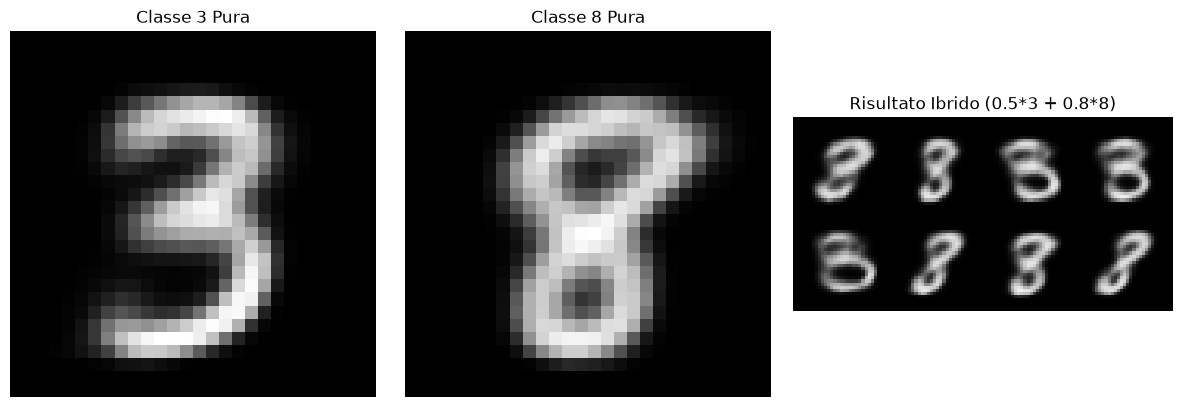

Analisi per la classe:
Il vettore di condizione risultante è:
[[0.  0.  0.  0.5 0.  0.  0.  0.  0.8 0. ]]


: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# --- CONFIGURAZIONE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 2  
batch_size = 128
epochs = 15
lr = 1e-3

transform = transforms.Compose([transforms.ToTensor()])

train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(datasets.MNIST('.', train=False, transform=transform), batch_size=1000, shuffle=False)

def to_one_hot(labels, num_classes=10):
    return torch.eye(num_classes).to(device)[labels]

# --- ARCHITETTURA CVAE ---
class CVAE(nn.Module):
    def __init__(self, feature_dim=784, class_dim=10, latent_dim=2):
        super().__init__()
        
        self.enc_fc = nn.Sequential(
            nn.Linear(feature_dim + class_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(200, latent_dim)
        self.fc_logvar = nn.Linear(200, latent_dim)

        self.dec_fc = nn.Sequential(
            nn.Linear(latent_dim + class_dim, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, feature_dim),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        x_cond = torch.cat([x.view(-1, 784), c], dim=1)
        h = self.enc_fc(x_cond)
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        z_cond = torch.cat([z, c], dim=1)
        return self.dec_fc(z_cond), mu, logvar

# --- TRAINING ---
model = CVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

def loss_function(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

print("Addestramento in corso...")
model.train()
for epoch in range(epochs):
    total_loss = 0
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        one_hot_labels = to_one_hot(labels)
        optimizer.zero_grad()
        recon, mu, logvar = model(data, one_hot_labels)
        loss = loss_function(recon, data, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

# --- SOLUZIONE ESERCIZIO: SOFT LABEL INTERPOLATION ---
model.eval()
print("\nEsecuzione esperimento 'Soft Labels'...")

with torch.no_grad():
    # 1. Definiamo i vettori One-Hot puri per il 3 e l'8
    label_3 = to_one_hot(torch.tensor([3]))
    label_8 = to_one_hot(torch.tensor([8]))

    # 2. Creiamo la condizione "mista" come richiesto
    # Nota: c = 0.5 * class_3 + 0.8 * class_8
    # Questo vettore avrà 0.5 alla posizione 3 e 0.8 alla posizione 8
    c_mista = (0.5 * label_3) + (0.8 * label_8)

    # 3. Generiamo diverse varianti usando lo stesso vettore c_mista
    # ma diversi punti nello spazio latente z (stile)
    z_varianti = torch.randn(8, latent_dim).to(device)
    
    # Prepariamo la condizione mista per 8 immagini
    c_batch = c_mista.repeat(8, 1) 
    
    # Generazione
    input_decoder = torch.cat([z_varianti, c_batch], dim=1)
    immagini_generate = model.dec_fc(input_decoder).cpu().view(8, 1, 28, 28)

    # --- VISUALIZZAZIONE RISULTATI ---
    plt.figure(figsize=(12, 4))
    
    # Plot 1: Le classi pure per confronto
    plt.subplot(1, 3, 1)
    test_z = torch.zeros(1, latent_dim).to(device)
    img_3 = model.dec_fc(torch.cat([test_z, label_3], dim=1)).cpu().view(28,28)
    plt.imshow(img_3, cmap='gray')
    plt.title("Classe 3 Pura")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    img_8 = model.dec_fc(torch.cat([test_z, label_8], dim=1)).cpu().view(28,28)
    plt.imshow(img_8, cmap='gray')
    plt.title("Classe 8 Pura")
    plt.axis('off')

    # Plot 2: Il risultato dell'esperimento
    plt.subplot(1, 3, 3)
    grid = utils.make_grid(immagini_generate, nrow=4)
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Risultato Ibrido (0.5*3 + 0.8*8)")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    print("Analisi per la classe:")
    print("Il vettore di condizione risultante è:")
    print(c_mista.cpu().numpy())